<a href="https://colab.research.google.com/github/roberto-ferreira-0/atividade-fase5-fiap/blob/main/RobertoFerreira_rm561131_pbl_fase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_wine, fetch_california_housing, make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV,cross_validate
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor, KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [ ]:
df = pd.read_csv('data/crop_yield.csv')

**ANÁLISE EXPLORATÓRIA**

Através da análise exploratória, notamos que se trata de um dataset bem comportado, sem dados nulos e com os dtypes apropriados.


Notamos também, ao usar o método .describe, que há uma variação considerável entre o valor mínimo e máximo na coluna "Yield", apontando para uma importante flutuação na produção de cada cultura, bem como um valor de desvio padrão maior que a média, o que pode indicar acentuada dispersão dos dados. Tais discrepâncias não se apresentam nas demais variáveis.

Ademais, notamos a presença de valores duplicados. Isso não aponta necessariamente, porém, um problema, podendo indicar similaridades características das diferentes culturas.

Através do mapa de calor, observamos a relação consideravelmente forte entre umidade relativa a 2 metros e precipitação diária, e temperatura e umidade específica a 2 metros. As demais colunas apresentam relações pouco contundentes.

Por fim, o boxplot nos mostra a presença de outliers, concentrados nas colunas "Temperature at 2 Meters (c)" e, principalmente, "Yield".

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [ ]:
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [ ]:
df.isna().sum()

,0
Crop,0
Precipitation (mm day-1),0
Specific Humidity at 2 Meters (g/kg),0
Relative Humidity at 2 Meters (%),0
Temperature at 2 Meters (C),0
Yield,0


In [ ]:
for col in df.columns:
  print(df[col].value_counts()[lambda x: x > 1])

Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64
Precipitation (mm day-1)
2248.92    4
1938.42    4
2301.54    4
2592.35    4
2344.72    4
2339.30    4
2326.09    4
2718.08    4
2061.61    4
1934.62    4
2217.12    4
2249.70    4
2530.96    4
2504.70    4
2686.20    4
2414.79    4
1999.53    4
2362.80    4
2792.95    4
2751.24    4
2646.28    4
2302.99    4
2692.34    4
2424.55    4
2363.63    4
2892.78    4
2729.53    4
3085.79    4
2922.18    4
2546.33    4
2938.29    4
2771.73    4
2607.96    4
2604.59    4
2308.51    4
2410.13    4
2967.41    4
2333.46    4
2109.34    4
Name: count, dtype: int64
Specific Humidity at 2 Meters (g/kg)
17.61    8
18.37    8
18.19    8
18.38    8
18.22    8
18.43    8
17.72    4
18.09    4
17.54    4
17.94    4
17.80    4
18.01    4
18.03    4
18.15    4
18.30    4
17.81    4
17.70    4
18.70    4
18.20    4
18.18    4
18.31    4
18.40    4
18.28    4
18.35    4
18.24    4
18.49    4


In [ ]:
for col in df.columns:
  print(f'{col}: {df[col].duplicated().sum()}')

Crop: 152
Precipitation (mm day-1): 117
Specific Humidity at 2 Meters (g/kg): 123
Relative Humidity at 2 Meters (%): 118
Temperature at 2 Meters (C): 127
Yield: 1


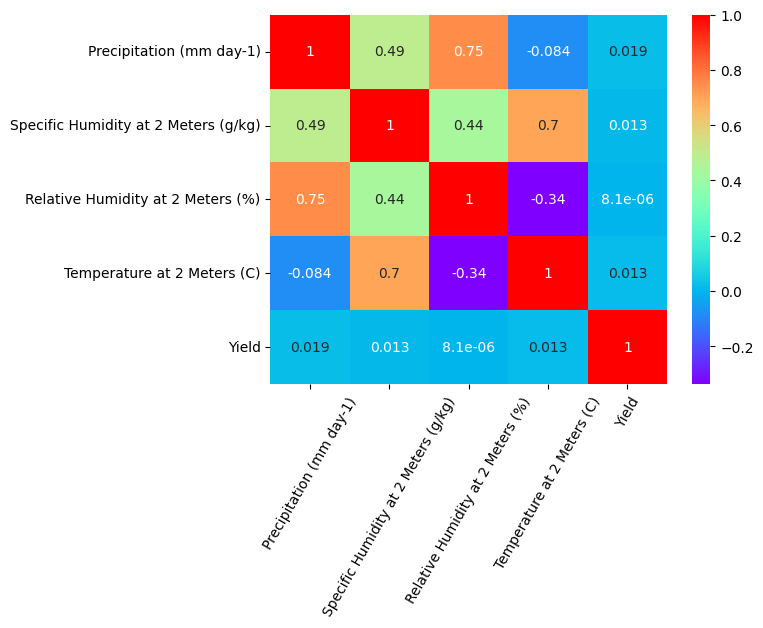

In [ ]:
sns.heatmap(df.select_dtypes(include=['int16','int32','int64','float16','float32','float64']).corr(),annot=True,cmap='rainbow')
plt.xticks(rotation=60);

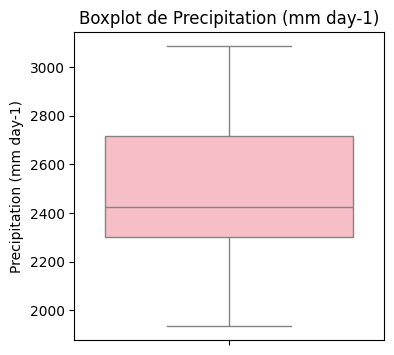

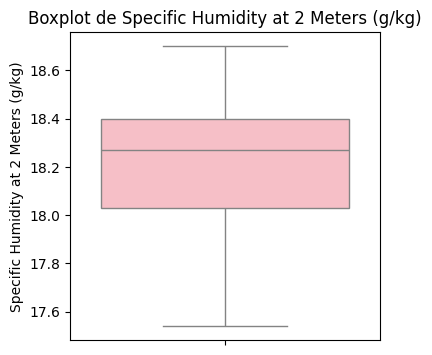

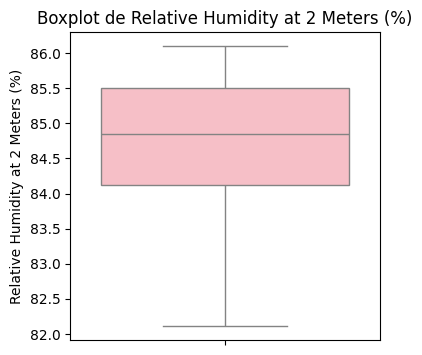

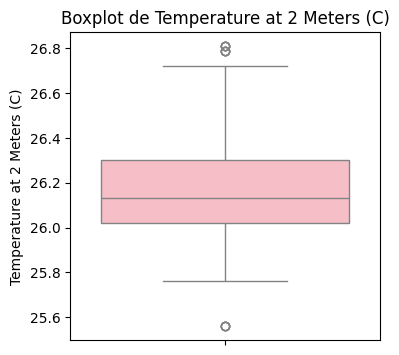

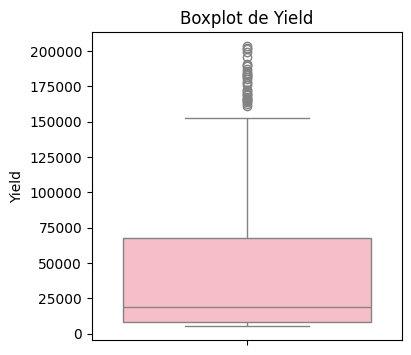

In [ ]:
for col in df.select_dtypes(include="number").columns:
  plt.figure(figsize=(4,4))
  sns.boxplot(data=df[col],color='lightpink')
  plt.xticks(rotation=45)
  plt.title(f'Boxplot de {col}')
  plt.show()

**MODELOS DE REGRESSÃO**

Os modelos de regressão escolhidos foram o Random Forest, Linear Regression, Ridge, Gradient Boosting e Decision Tree. Para todos os modelos, as métricas foram R2, MAE,MSE e RMSE.

Todos os modelos apresentaram desempenho semelhantemente satisfatório. Destaque para o Linear Regression, que apresentou o melhor R2 (1.00), melhor RMSE (4394.17) e menor taxa de erro médio (9.26%), possivelmente se apresentando como o melhor modelo.

In [ ]:
x = df.drop(columns=('Yield'))
y = df['Yield']

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [ ]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore'))
])

cat_cols = ['Crop']
num_cols = [col for col in x_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('numerica',num_trans,num_cols),
    ('categorica',cat_trans,cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessador',preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=200))
])

pipeline.fit(x_train,y_train)
model_pred = pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
print(f'R2: {r2_score(y_test,model_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test,model_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test,model_pred):.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Variação percentual da produção média: {(rmse / y_test.mean())*100:.2f}%')

R2: 0.99
MAE: 2729.69
MSE: 23119487.30
RMSE: 4808.27
Variação percentual da produção média: 10.13%


In [ ]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore'))
])

cat_cols = ['Crop']
num_cols = [col for col in x_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('numerica',num_trans,num_cols),
    ('categorica',cat_trans,cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessador',preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(x_train,y_train)
model_pred = pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
print(f'R2: {r2_score(y_test,model_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test,model_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test,model_pred):.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Variação percentual da produção média: {(rmse / y_test.mean())*100:.2f}%')

R2: 1.00
MAE: 3132.80
MSE: 19308693.24
RMSE: 4394.17
Variação percentual da produção média: 9.26%


In [ ]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore'))
])

cat_cols = ['Crop']
num_cols = [col for col in x_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('numerica',num_trans,num_cols),
    ('categorica',cat_trans,cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessador',preprocessor),
    ('regressor', Ridge())
])

pipeline.fit(x_train,y_train)
model_pred = pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
print(f'R2: {r2_score(y_test,model_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test,model_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test,model_pred):.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Variação percentual da produção média: {(rmse / y_test.mean())*100:.2f}%')

R2: 0.99
MAE: 3400.84
MSE: 23669464.82
RMSE: 4865.13
Variação percentual da produção média: 10.25%


In [ ]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore'))
])

cat_cols = ['Crop']
num_cols = [col for col in x_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('numerica',num_trans,num_cols),
    ('categorica',cat_trans,cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessador',preprocessor),
    ('regressor', GradientBoostingRegressor())
])

pipeline.fit(x_train,y_train)
model_pred = pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
print(f'R2: {r2_score(y_test,model_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test,model_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test,model_pred):.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Variação percentual da produção média: {(rmse / y_test.mean())*100:.2f}%')

R2: 0.99
MAE: 3065.81
MSE: 36672022.41
RMSE: 6055.74
Variação percentual da produção média: 12.76%


In [ ]:
num_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

cat_trans = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('scaler',OneHotEncoder(handle_unknown='ignore'))
])

cat_cols = ['Crop']
num_cols = [col for col in x_train.columns if col not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('numerica',num_trans,num_cols),
    ('categorica',cat_trans,cat_cols)
])

pipeline = Pipeline(steps=[
    ('preprocessador',preprocessor),
    ('regressor', DecisionTreeRegressor())
])

pipeline.fit(x_train,y_train)
model_pred = pipeline.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test, model_pred))
print(f'R2: {r2_score(y_test,model_pred):.2f}')
print(f'MAE: {mean_absolute_error(y_test,model_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test,model_pred):.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'Variação percentual da produção média: {(rmse / y_test.mean())*100:.2f}%')

R2: 0.99
MAE: 3147.56
MSE: 29282445.69
RMSE: 5411.33
Variação percentual da produção média: 11.41%
